In [11]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from unidecode import unidecode

In [12]:
CSV_PATH = "../outputs/prediksi_2024.csv"  # ganti kalau nama file CSV berbeda
SHP_PATH = "../maps/BATAS KABUPATEN KOTA DESEMBER 2019 DUKCAPIL.shp"  # ganti kalau beda


In [13]:
STOPWORDS = [
    "KABUPATEN", "KAB.", "KOTA", "ADM.", "DAERAH", "ISTIMEWA",
    "REGENCY", "REGENCIES", "CITY", "KAB", "KAB/KOTA"
]

REPLACEMENTS = {
    # koreksi ejaan umum (sesuaikan jika perlu)
    "PATI REGENCY": "PATI",
    "MAGELANG REGENCY": "MAGELANG",
    "SEMARANG REGENCY": "SEMARANG",
}

def normalize_name(s: str) -> str:
    if pd.isna(s):
        return s
    s = str(s)
    s = unidecode(s)              # hilangkan aksen, samakan ASCII
    s = s.replace("-", " ")
    s = s.replace("/", " ")
    s = s.strip().upper()

    # hapus prefix umum
    for w in STOPWORDS:
        s = s.replace(f"{w} ", " ")
        s = s.replace(f" {w}", " ")
    s = " ".join(s.split())       # collapse spasi

    # mapping manual (jika ada)
    if s in REPLACEMENTS:
        s = REPLACEMENTS[s]

    return s

In [14]:
df = pd.read_csv(CSV_PATH)

if "Wilayah" not in df.columns or "P1" not in df.columns or "prediksi" not in df.columns:
    raise ValueError("Pastikan CSV punya kolom: 'Wilayah', 'P1', 'prediksi'.")

df["join_key"] = df["Wilayah"].apply(normalize_name)


In [15]:
gdf = gpd.read_file(SHP_PATH)
print("Kolom shapefile:", list(gdf.columns))
print(gdf.head(2))


Kolom shapefile: ['KAB_KOTA', 'geometry']
     KAB_KOTA                                           geometry
0        None  MULTIPOLYGON (((116.20336 -8.7544, 116.20314 -...
1  ACEH BARAT  POLYGON ((96.11425 4.14761, 96.11439 4.14799, ...


In [16]:
COMMON_NAME_COLS = [
    "NAMOBJ", "WADMKC", "WADMKK", "KABUPATEN", "KAB_KOTA",
    "KABKOT", "NAMA_KAB", "NAME_2", "KABKO", "WADMPR", "WADMKAB",
]

name_col = None
for c in COMMON_NAME_COLS:
    if c in gdf.columns:
        name_col = c
        break

if name_col is None:
    # pilih dari kolom bertipe object yang paling mirip ke daftar wilayah csv
    obj_cols = [c for c in gdf.columns if gdf[c].dtype == "object"]
    csv_names = set(df["join_key"])
    best_col, best_score = None, -1
    for c in obj_cols:
        cand = gdf[c].astype(str).apply(normalize_name)
        overlap = len(set(cand) & csv_names)
        if overlap > best_score:
            best_col, best_score = c, overlap
    name_col = best_col

if name_col is None:
    raise ValueError("Tidak menemukan kolom nama wilayah di shapefile. Cek struktur shapefile Anda.")

print(f"[INFO] Kolom nama wilayah terdeteksi: {name_col}")

[INFO] Kolom nama wilayah terdeteksi: KAB_KOTA


In [17]:
gdf["join_key"] = gdf[name_col].apply(normalize_name)

merged = gdf.merge(
    df[["join_key", "P1", "prediksi"]],
    on="join_key",
    how="left"
)

total = len(merged)
matched = merged["P1"].notna().sum()
print(f"[INFO] Match setelah merge: {matched} / {total}")

# Tampilkan yang belum ketemu (agar mudah dibenahi jika ada selisih nama)
if matched < total:
    not_found = merged.loc[merged["P1"].isna(), [name_col, "join_key"]].drop_duplicates()
    print("\n[WARN] Wilayah belum match (contoh):")
    print(not_found.head(20))

[INFO] Match setelah merge: 43 / 523

[WARN] Wilayah belum match (contoh):
           KAB_KOTA         join_key
0              None             None
1        ACEH BARAT       ACEH BARAT
2   ACEH BARAT DAYA  ACEH BARAT DAYA
3        ACEH BESAR       ACEH BESAR
4         ACEH JAYA        ACEH JAYA
5      ACEH SELATAN     ACEH SELATAN
6      ACEH SINGKIL     ACEH SINGKIL
7      ACEH TAMIANG     ACEH TAMIANG
8       ACEH TENGAH      ACEH TENGAH
9     ACEH TENGGARA    ACEH TENGGARA
10       ACEH TIMUR       ACEH TIMUR
11       ACEH UTARA       ACEH UTARA
12             AGAM             AGAM
13             ALOR             ALOR
14           ASAHAN           ASAHAN
15            ASMAT            ASMAT
16           BADUNG           BADUNG
17         BALANGAN         BALANGAN
18          BANDUNG          BANDUNG
19    BANDUNG BARAT    BANDUNG BARAT


In [18]:
if merged.empty or merged.geometry.isna().all():
    ax = gdf.plot(edgecolor="black", facecolor="none", figsize=(6,6))
    ax.set_title("Cek Shapefile (baseline)"); ax.axis("off")
    raise SystemExit("Shapefile OK, tapi merge/kolom data belum benar. Lihat [WARN] di atas.")


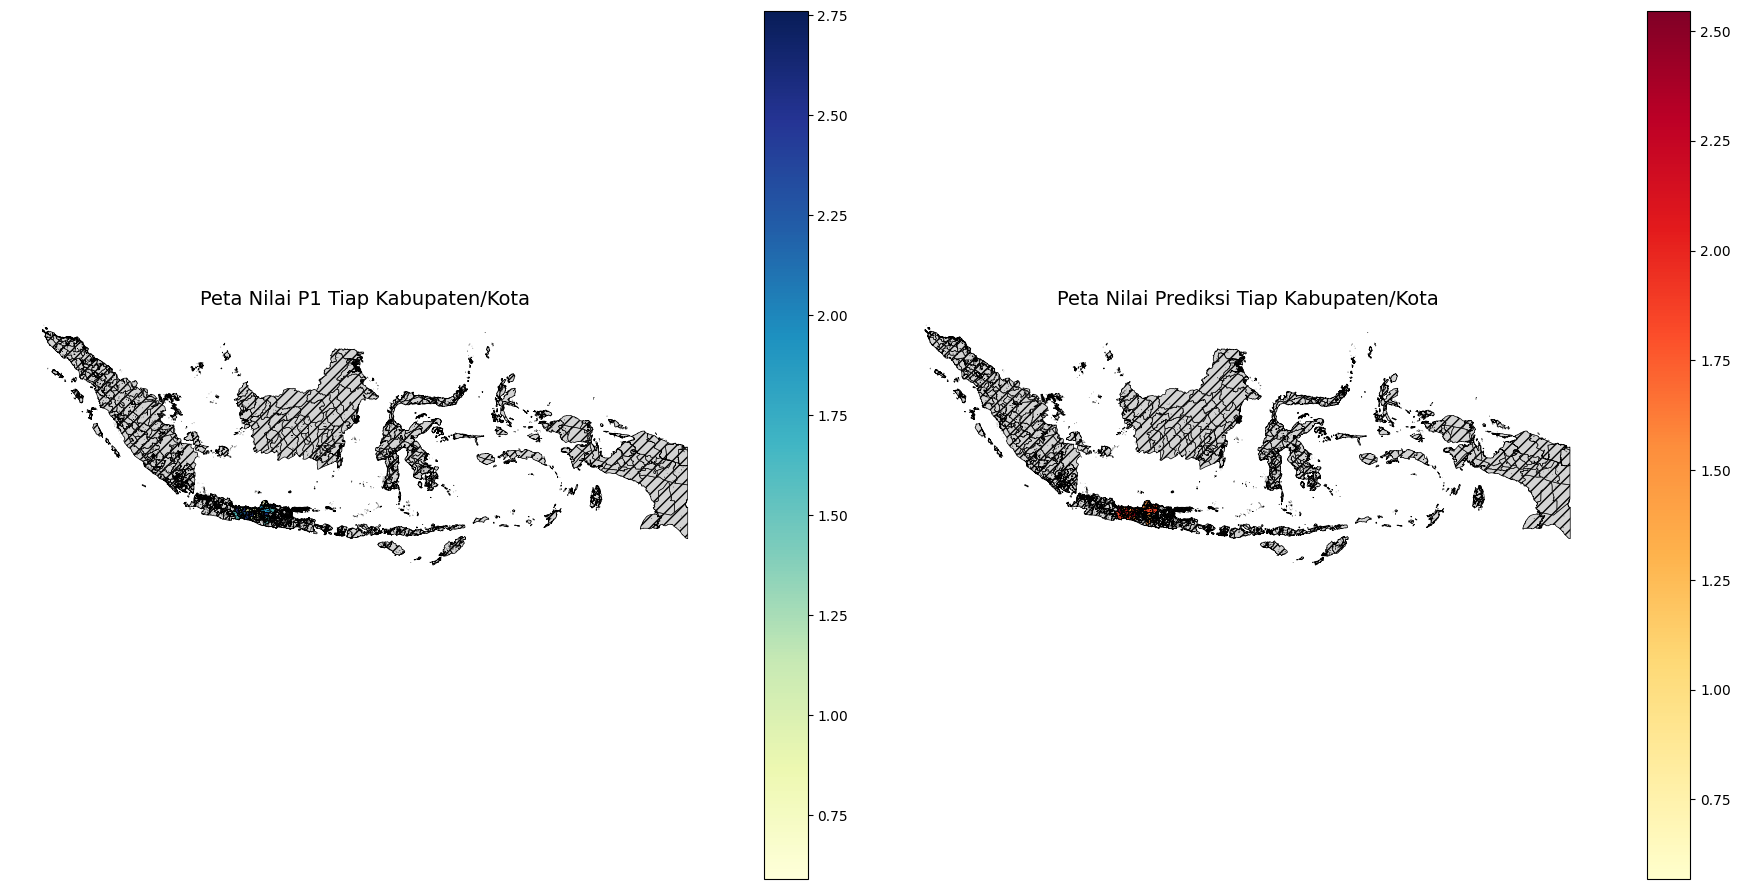

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# gunakan missing_kwds supaya area tanpa data tetap terlihat
missing_style = {"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Tidak ada data"}

vmin_p1, vmax_p1 = merged["P1"].min(skipna=True), merged["P1"].max(skipna=True)
vmin_pr, vmax_pr = merged["prediksi"].min(skipna=True), merged["prediksi"].max(skipna=True)

# --- Peta P1 ---
merged.plot(
    column="P1", ax=axes[0], cmap="YlGnBu",
    edgecolor="black", linewidth=0.5, legend=True,
    missing_kwds=missing_style, vmin=vmin_p1, vmax=vmax_p1
)
axes[0].set_title("Peta Nilai P1 Tiap Kabupaten/Kota", fontsize=14)
axes[0].axis("off")

# --- Peta Prediksi ---
merged.plot(
    column="prediksi", ax=axes[1], cmap="YlOrRd",
    edgecolor="black", linewidth=0.5, legend=True,
    missing_kwds=missing_style, vmin=vmin_pr, vmax=vmax_pr
)
axes[1].set_title("Peta Nilai Prediksi Tiap Kabupaten/Kota", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()


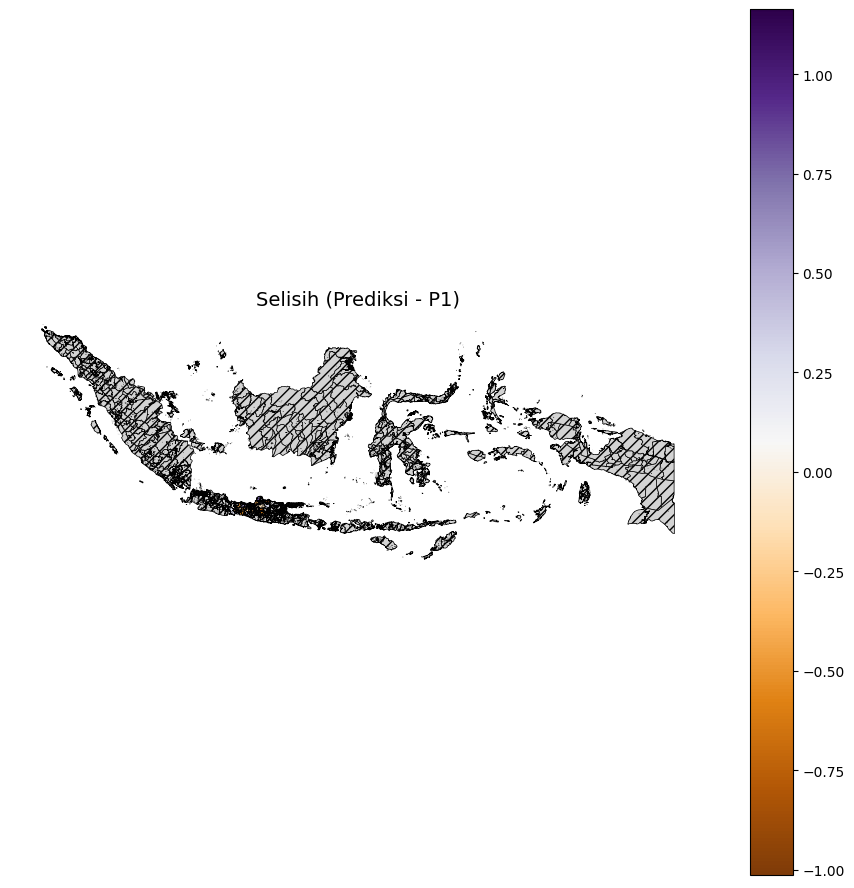

In [22]:
try:
    merged["selisih"] = merged["prediksi"] - merged["P1"]
    fig2, ax2 = plt.subplots(figsize=(9, 9))
    merged.plot(
        column="selisih", ax=ax2, cmap="PuOr",
        edgecolor="black" \
        "", linewidth=0.5, legend=True,
        missing_kwds=missing_style
    )
    ax2.set_title("Selisih (Prediksi - P1)", fontsize=14)
    ax2.axis("off")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("[INFO] Lewati peta selisih:", e)

In [23]:
# =========================
# Filter ke Provinsi JAWA TENGAH (kalau shapefile nasional)
# =========================
def _norm(s):
    import pandas as pd
    from unidecode import unidecode
    if pd.isna(s): return s
    s = unidecode(str(s)).strip().upper()
    s = s.replace("PROVINSI ", "")
    return s

# Kandidat nama kolom provinsi yang umum dipakai
PROV_COLS = ["PROVINSI", "WADMPR", "PROPINSI", "PROVNAME", "NAME_1", "provinsi", "Provinsi"]

prov_col = next((c for c in PROV_COLS if c in gdf.columns), None)

if prov_col is not None:
    gdf["_prov_norm"] = gdf[prov_col].apply(_norm)
    # Nilai target
    TARGET = {"JAWA TENGAH", "JAWA  TENGAH"}  # tambahkan variasi jika perlu
    gdf = gdf[gdf["_prov_norm"].isin(TARGET)].copy()

    if gdf.empty:
        print("[WARN] Tidak menemukan poligon 'Jawa Tengah' di kolom", prov_col,
              "— kemungkinan shapefile memang sudah subset Jateng atau nama kolom/isinya berbeda.")
else:
    print("[INFO] Kolom provinsi tidak ditemukan. Melewatkan filter (diasumsikan shapefile sudah Jateng).")


[INFO] Kolom provinsi tidak ditemukan. Melewatkan filter (diasumsikan shapefile sudah Jateng).


In [27]:
import pandas as pd
import geopandas as gpd
import numpy as np
from unidecode import unidecode
import plotly.graph_objects as go
import json
from pathlib import Path
import webbrowser

In [28]:
CSV_PATH = "../outputs/prediksi_2024.csv"  # ganti jika nama file CSV berbeda
SHP_PATH = "../maps/BATAS KABUPATEN KOTA DESEMBER 2019 DUKCAPIL.shp"  # ganti jika perlu
OUT_HTML = "../outputs/dashboard_peta_perbandingan_prediksi.html"  # <--- nama baru


In [29]:
def norm(s):
    if pd.isna(s): return s
    s = unidecode(str(s)).upper().strip()
    s = s.replace("-", " ").replace("/", " ")
    # hapus kata umum
    for w in ["KABUPATEN ", "KOTA ", "KAB. ", "ADM. ", "DAERAH ", "ISTIMEWA "]:
        s = s.replace(w, "")
    return " ".join(s.split())


In [30]:
df = pd.read_csv(CSV_PATH)
req = {"Wilayah","P1","prediksi"}
if not req.issubset(df.columns):
    raise ValueError(f"CSV harus punya kolom {req}")
df["join_key"] = df["Wilayah"].apply(norm)


In [31]:
gdf = gpd.read_file(SHP_PATH)

# (opsional) filter ke JAWA TENGAH jika shapefile nasional
prov_cols = [c for c in ["PROVINSI","WADMPR","PROPINSI","PROVNAME","NAME_1","provinsi","Provinsi"] if c in gdf.columns]
if prov_cols:
    pc = prov_cols[0]
    gdf["_prov"] = gdf[pc].apply(norm)
    gdf = gdf[gdf["_prov"] == "JAWA TENGAH"].copy()
    if gdf.empty:
        print("[WARN] Tidak ditemukan provinsi 'Jawa Tengah' — kemungkinan shapefile sudah subset Jateng.")

# deteksi kolom nama wilayah
candidates = ["NAMOBJ","WADMKC","WADMKK","KABUPATEN","KAB_KOTA","KABKOT","NAMA_KAB","NAME_2","KABKO","WADMKAB"]
name_col = next((c for c in candidates if c in gdf.columns), None)
if name_col is None:
    # fallback: ambil kolom object dengan overlap terbesar
    obj_cols = [c for c in gdf.columns if gdf[c].dtype=='object']
    csv_keys = set(df["join_key"])
    best,score = None,-1
    for c in obj_cols:
        cand = set(gdf[c].astype(str).apply(norm))
        sc = len(cand & csv_keys)
        if sc > score:
            best,score = c,sc
    name_col = best if best else obj_cols[0]

print(f"[INFO] Kolom nama wilayah: {name_col}")
gdf["join_key"] = gdf[name_col].apply(norm)


[INFO] Kolom nama wilayah: KAB_KOTA


In [32]:
merged = gdf.merge(df[["join_key","P1","prediksi"]], on="join_key", how="left")

print("Match:", merged["P1"].notna().sum(), "/", len(merged))
if merged["P1"].isna().any():
    print("[PERINGATAN] Ada wilayah belum match. Contoh:")
    print(merged.loc[merged["P1"].isna(), [name_col,"join_key"]].drop_duplicates().head(10))

# pastikan CRS WGS84 (untuk plotly)
try:
    if merged.crs is None or merged.crs.to_epsg() != 4326:
        merged = merged.to_crs(4326)
except Exception:
    pass

geojson = json.loads(merged.to_json())

Match: 43 / 523
[PERINGATAN] Ada wilayah belum match. Contoh:
          KAB_KOTA         join_key
0             None             None
1       ACEH BARAT       ACEH BARAT
2  ACEH BARAT DAYA  ACEH BARAT DAYA
3       ACEH BESAR       ACEH BESAR
4        ACEH JAYA        ACEH JAYA
5     ACEH SELATAN     ACEH SELATAN
6     ACEH SINGKIL     ACEH SINGKIL
7     ACEH TAMIANG     ACEH TAMIANG
8      ACEH TENGAH      ACEH TENGAH
9    ACEH TENGGARA    ACEH TENGGARA


In [33]:
vmin = float(min(merged["P1"].min(skipna=True), merged["prediksi"].min(skipna=True)))
vmax = float(max(merged["P1"].max(skipna=True), merged["prediksi"].max(skipna=True)))

mean_p1 = float(merged["P1"].mean(skipna=True))
mean_pred = float(merged["prediksi"].mean(skipna=True))

locations = merged["join_key"]
custom = np.array(merged[name_col].fillna("-"))

In [34]:
hover_p1 = (
    "<b>%{customdata[0]}</b><br>"
    "P1: %{z:.2f} %<br>"
    f"<i>Rata-rata:</i> {mean_p1:.2f} %"
)
hover_pred = (
    "<b>%{customdata[0]}</b><br>"
    "Prediksi: %{z:.2f} %<br>"
    f"<i>Rata-rata:</i> {mean_pred:.2f} %"
)

trace_p1 = go.Choropleth(
    geojson=geojson,
    featureidkey="properties.join_key",
    locations=locations,
    z=merged["P1"],
    colorscale="OrRd",
    zmin=vmin, zmax=vmax,
    marker_line_width=0.5,
    marker_line_color="white",
    colorbar_title="P1 (%)",
    hovertemplate=hover_p1,
    customdata=np.c_[custom],
    visible=True
)

trace_pred = go.Choropleth(
    geojson=geojson,
    featureidkey="properties.join_key",
    locations=locations,
    z=merged["prediksi"],
    colorscale="OrRd",
    zmin=vmin, zmax=vmax,
    marker_line_width=0.5,
    marker_line_color="white",
    colorbar_title="Prediksi (%)",
    hovertemplate=hover_pred,
    customdata=np.c_[custom],
    visible=False
)

In [ ]:
title_base = "Indeks Kedalaman Kemiskinan"
subtitle_p1 = f"Provinsi Jawa Tengah • Rata-rata: {mean_p1:.2f}% • Range: {vmin:.2f}–{vmax:.2f}%"
subtitle_pred = f"Provinsi Jawa Tengah • Rata-rata: {mean_pred:.2f}% • Range: {vmin:.2f}–{vmax:.2f}%"

fig = go.Figure(data=[trace_p1, trace_pred])

fig.update_layout(
    title=dict(
        text=f"<b>{title_base}</b><br><span style='font-size:12px'>{subtitle_p1}</span>",
        x=0.5
    ),
    margin=dict(l=40, r=40, t=80, b=40),
    geo=dict(
        fitbounds="locations",
        visible=False,
        projection_type="mercator"
    ),
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label="Indeks Kedalaman Kemiskinan (P1)",
                    method="update",
                    args=[
                        {"visible":[True, False]},
                        {"title":f"<b>{title_base}</b><br><span style='font-size:12px'>{subtitle_p1}</span>"}
                    ]
                ),
                dict(
                    label="Prediksi",
                    method="update",
                    args=[
                        {"visible":[False, True]},
                        {"title":f"<b>{title_base}</b><br><span style='font-size:12px'>{subtitle_pred}</span>"}
                    ]
                ),
            ],
            direction="down",
            x=0.05, xanchor="left",
            y=0.95, yanchor="top"
        )
    ],
    annotations=[
        dict(
            x=0.5, y=-0.05, xref="paper", yref="paper",
            text="Sumber: BPS Jawa Tengah (2024) • Prediksi oleh model internal",
            showarrow=False, font=dict(size=11, color="#555")
        )
    ]
)
